In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# ----------------- Load CIFAR-10 -----------------
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Normalize images
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# ----------------- Data Augmentation -----------------
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    shear_range=0.1
)
datagen.fit(x_train)

# ----------------- Model Architecture -----------------
model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

# ----------------- Compile Model -----------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ----------------- Learning Rate Scheduler -----------------
lr_reduction = ReduceLROnPlateau(
    monitor='val_accuracy',
    patience=3,
    factor=0.5,
    min_lr=1e-5,
    verbose=1
)

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=7,
    restore_best_weights=True
)

callbacks=[lr_reduction, early_stop]

# ----------------- Train Model -----------------
history = model.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=50,
    validation_data=(x_test, y_test),
    callbacks=[lr_reduction],
    verbose=2
)

# ----------------- Evaluate -----------------
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")

# ----------------- Save Model -----------------
model.save("lightweight_cnn_cifar10.h5")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 404,778 (1.54 MB)

 Trainable params: 403,882 (1.54 MB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/50
782/782 - 50s - 63ms/step - accuracy: 0.4147 - loss: 1.7033 - val_accuracy: 0.5606 - val_loss: 1.2270 - learning_rate: 0.0010
Epoch 2/50
782/782 - 33s - 42ms/step - accuracy: 0.5563 - loss: 1.2469 - val_accuracy: 0.5680 - val_loss: 1.2496 - learning_rate: 0.0010
Epoch 3/50
782/782 - 32s - 41ms/step - accuracy: 0.6180 - loss: 1.0825 - val_accuracy: 0.6591 - val_loss: 0.9742 - learning_rate: 0.0010
Epoch 4/50
782/782 - 32s - 40ms/step - accuracy: 0.6559 - loss: 0.9798 - val_accuracy: 0.6677 - val_loss: 0.9727 - learning_rate: 0.0010
Epoch 5/50
782/782 - 32s - 42ms/step - accuracy: 0.6753 - loss: 0.9271 - val_accuracy: 0.6904 - val_loss: 0.8803 - learning_rate: 0.0010
Epoch 6/50
782/782 - 32s - 41ms/step - accuracy: 0.6953 - loss: 0.8785 - val_accuracy: 0.7060 - val_loss: 0.8477 - learning_rate: 0.0010
Epoch 7/50
782/782 - 33s - 42ms/step - accuracy: 0.7090 - loss: 0.8419 - val_accuracy: 0.7147 - val_loss: 0.8235 - learning_rate: 0.0010
Epoch 8/50
782/782 - 31s - 40ms/step - ac


Test Accuracy: 84.29%


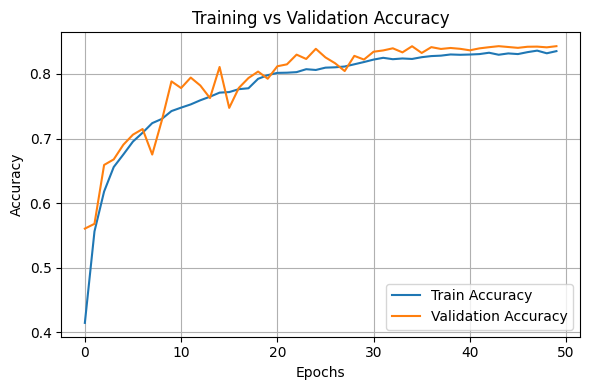

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid()
plt.tight_layout()

plt.savefig("accuracy_plot.png", dpi=300)
plt.show()

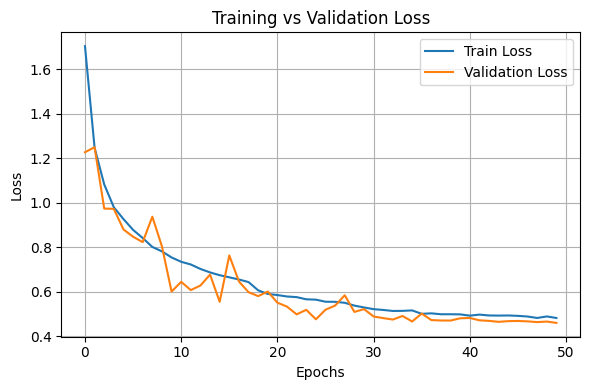

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid()
plt.tight_layout()

plt.savefig("loss_plot.png", dpi=300)
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step


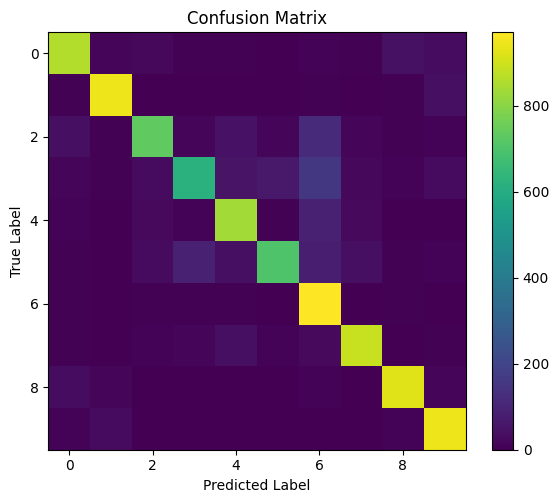

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

# Convert predictions
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Convert one-hot to labels
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,5))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

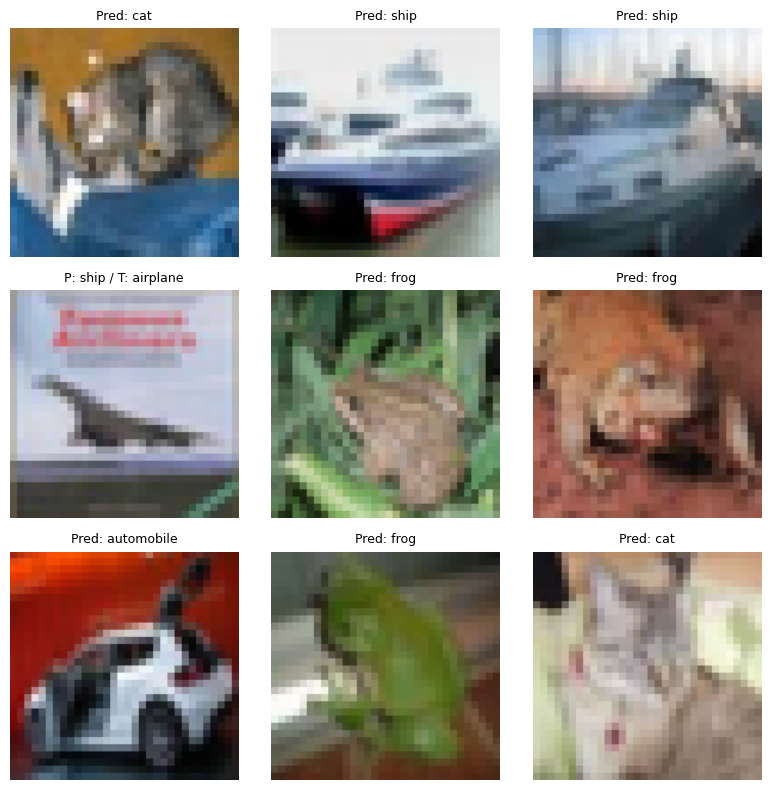

In [ ]:
import cv2

# CIFAR-10 class names
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

def upscale_image(img):
    return cv2.resize(img, (128, 128), interpolation=cv2.INTER_NEAREST)

plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)

    img = upscale_image(x_test[i])

    # Predict
    pred = np.argmax(model.predict(x_test[i].reshape(1,32,32,3), verbose=0))
    true = np.argmax(y_test[i])

    plt.imshow(img)

    if pred == true:
        plt.title(f"Pred: {class_names[pred]}", fontsize=9)
    else:
        plt.title(f"P: {class_names[pred]} / T: {class_names[true]}", fontsize=9)

    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes, target_names=class_names))

              precision    recall  f1-score   support

    airplane       0.87      0.86      0.87      1000
  automobile       0.93      0.94      0.94      1000
        bird       0.86      0.73      0.79      1000
         cat       0.82      0.62      0.71      1000
        deer       0.82      0.84      0.83      1000
         dog       0.88      0.70      0.78      1000
        frog       0.66      0.97      0.79      1000
       horse       0.89      0.89      0.89      1000
        ship       0.92      0.93      0.92      1000
       truck       0.87      0.95      0.91      1000

    accuracy                           0.84     10000
   macro avg       0.85      0.84      0.84     10000
weighted avg       0.85      0.84      0.84     10000

